In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
DATA_DIR = Path("../data")

In [6]:
def plot_and_save_history(dt, subset):
    """特定のパラメータのデータをグラフ化して保存する"""
    plt.figure(figsize=(15, 4))
    
    # 1. 人口の推移
    plt.subplot(1, 3, 1)
    # データ数が多いため、線の太さ(linewidth)を細くして見やすくしています
    plt.plot(subset['step'], subset['population'], color='blue', linewidth=0.5)
    plt.title('Population')
    plt.xlabel('Step')
    plt.ylabel('Count')
    
    # 2. 利他行動の推移
    plt.subplot(1, 3, 2)
    plt.plot(subset['step'], subset['altruism_count'], color='orange', linewidth=0.5)
    plt.title('Altruism Count')
    plt.xlabel('Step')
    
    # 3. 平均エネルギーの推移
    plt.subplot(1, 3, 3)
    plt.plot(subset['step'], subset['avg_energy'], color='green', linewidth=0.5)
    plt.title('Average Energy')
    plt.xlabel('Step')
    
    # タイトルとレイアウト調整
    plt.suptitle(f'Death Threshold: {dt:.1f}')
    plt.tight_layout()
    
    plt.show()    

Loading data from ../data/simulation_history.csv...
Generating plots...
Plotting: death_threshold=-200.0


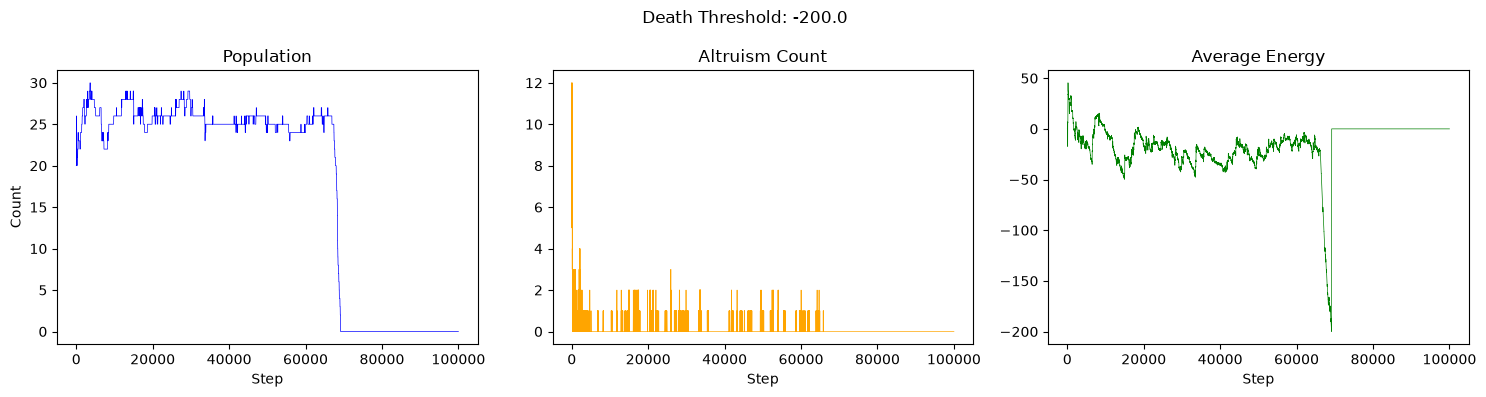

Plotting: death_threshold=-178.9


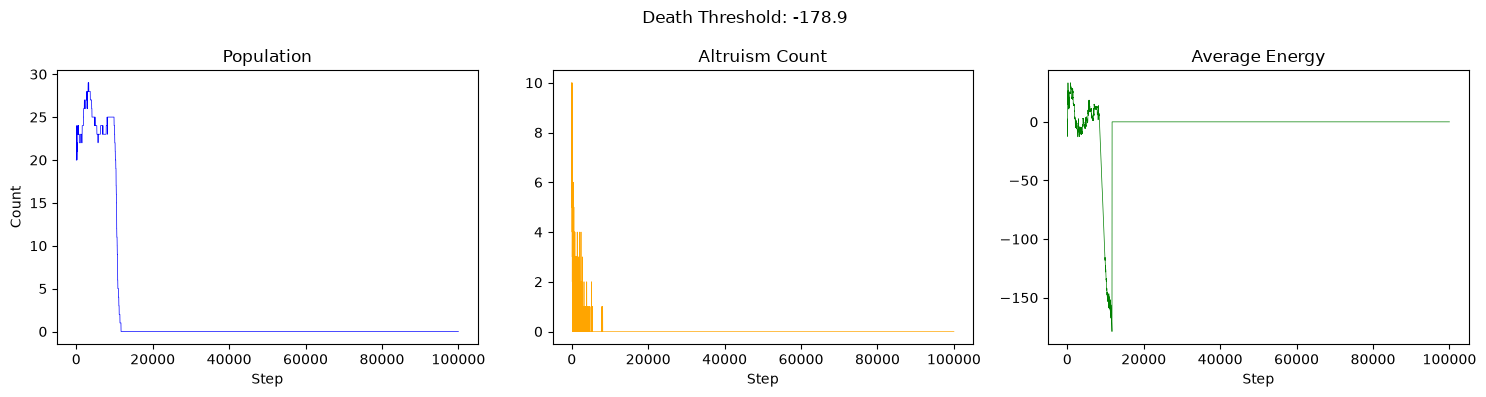

Plotting: death_threshold=-157.8


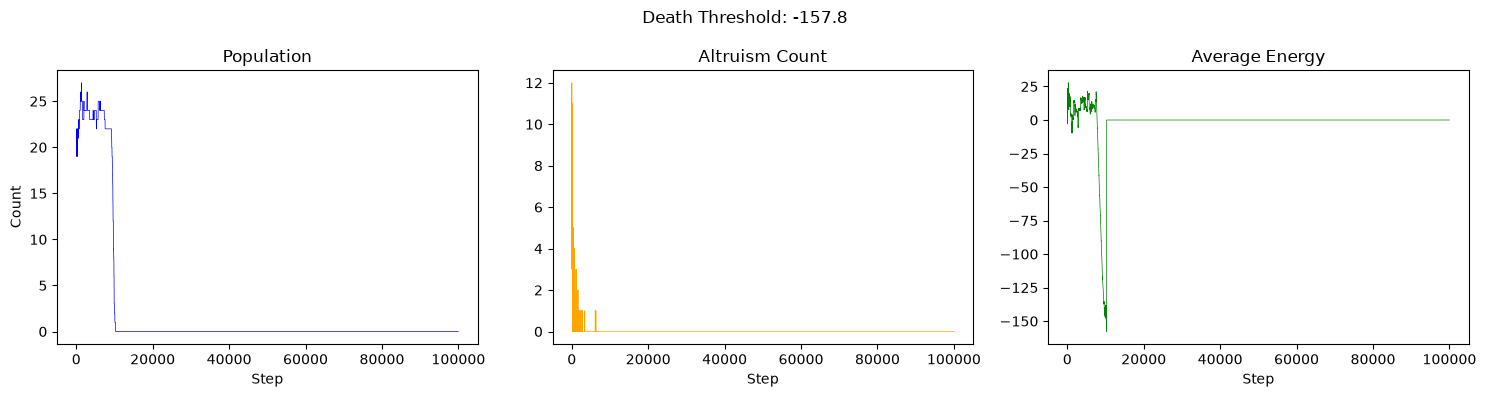

Plotting: death_threshold=-136.7


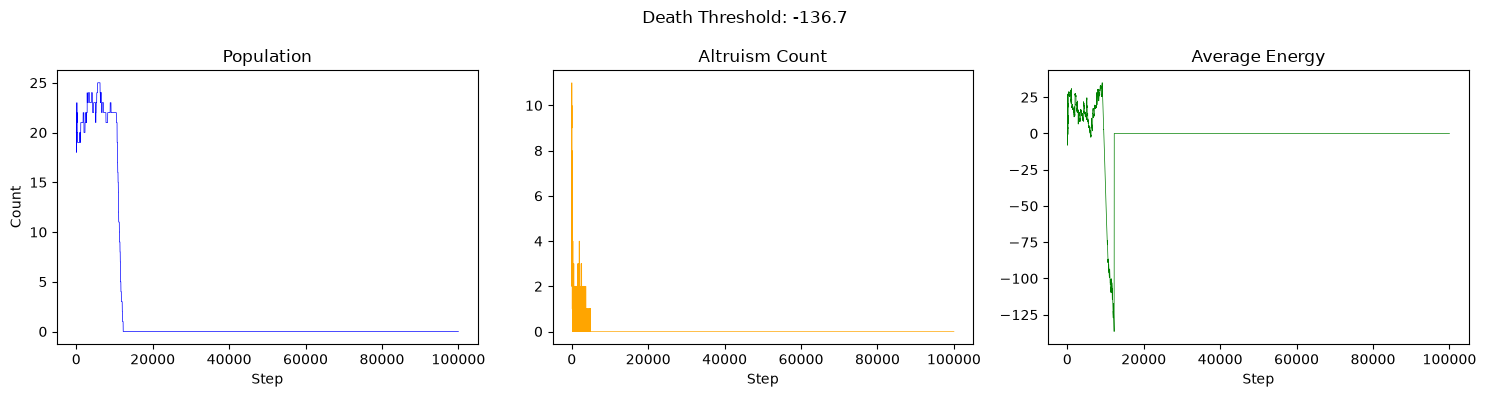

Plotting: death_threshold=-115.6


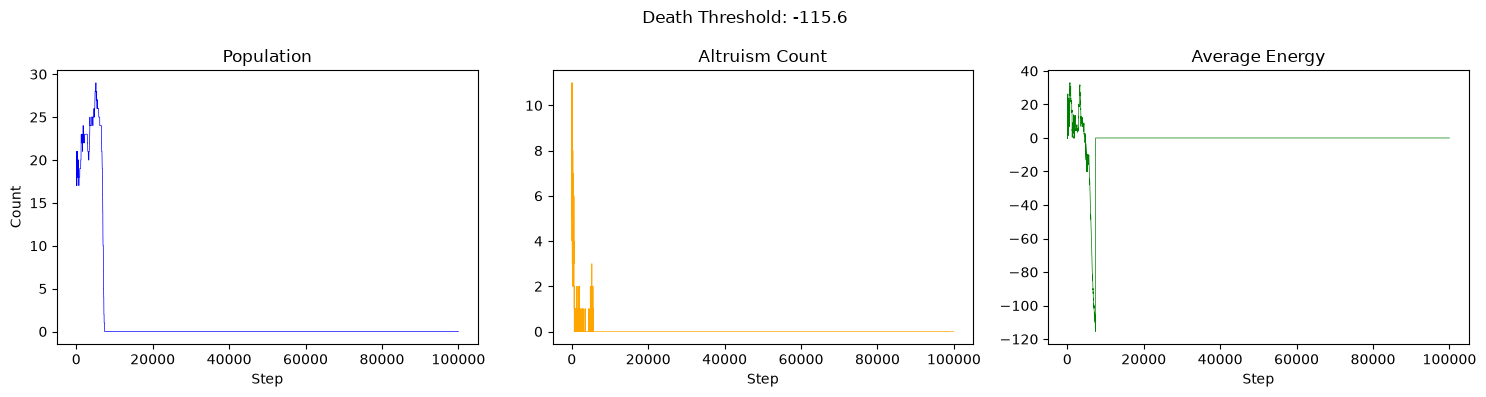

Plotting: death_threshold= -94.4


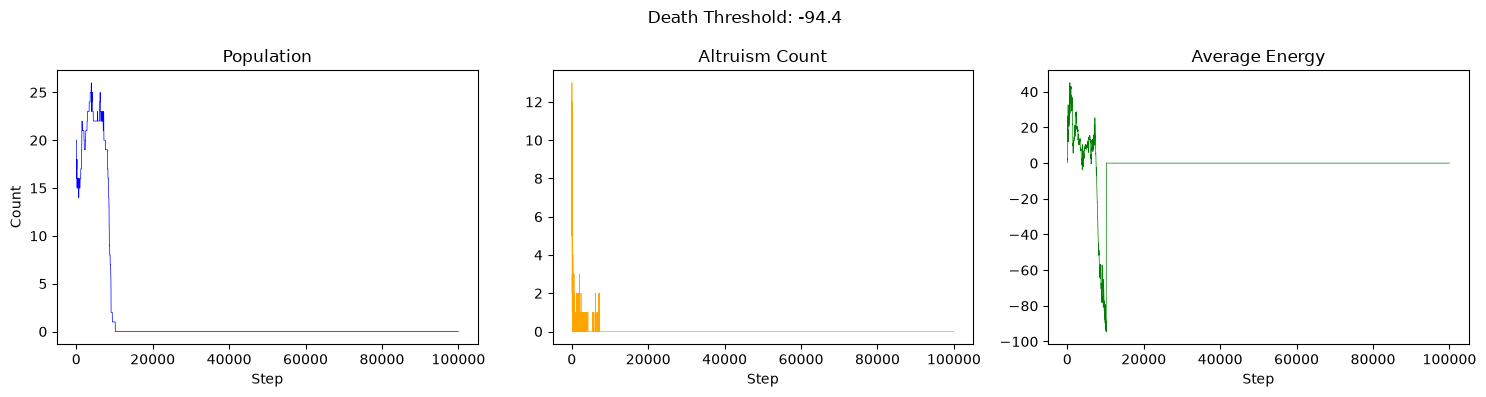

Plotting: death_threshold= -73.3


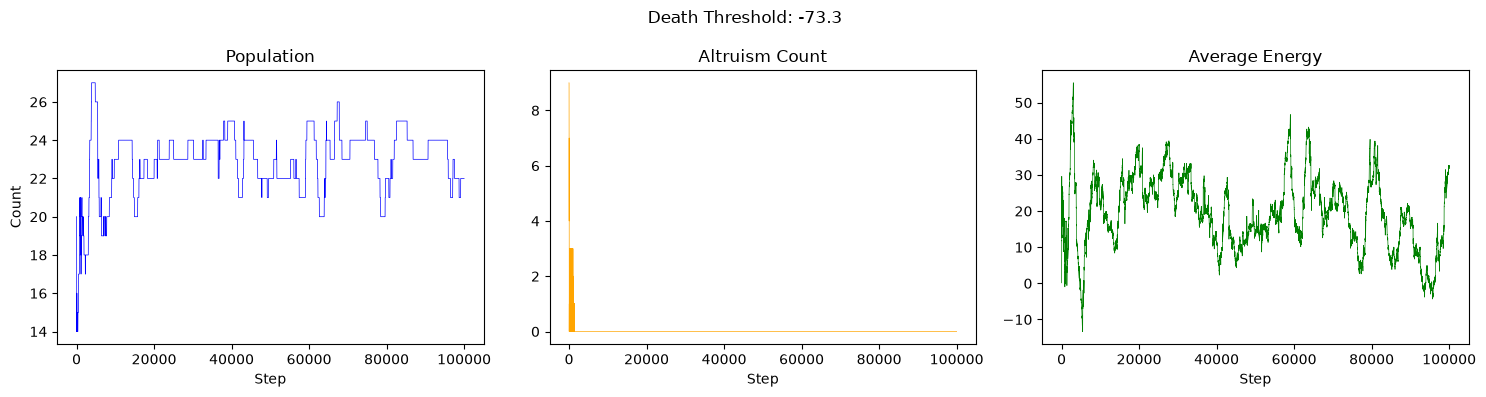

Plotting: death_threshold= -52.2


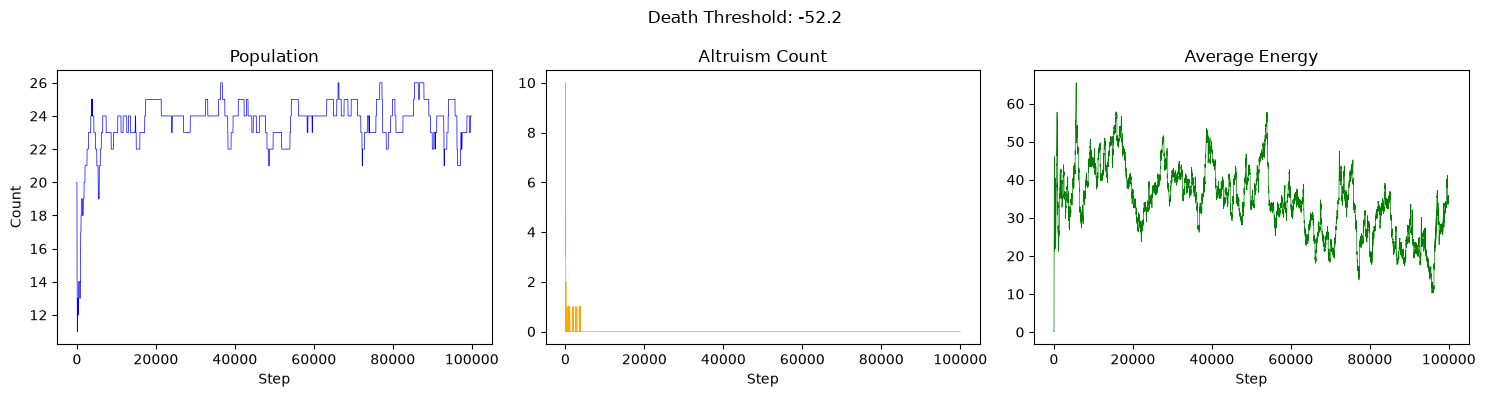

Plotting: death_threshold= -31.1


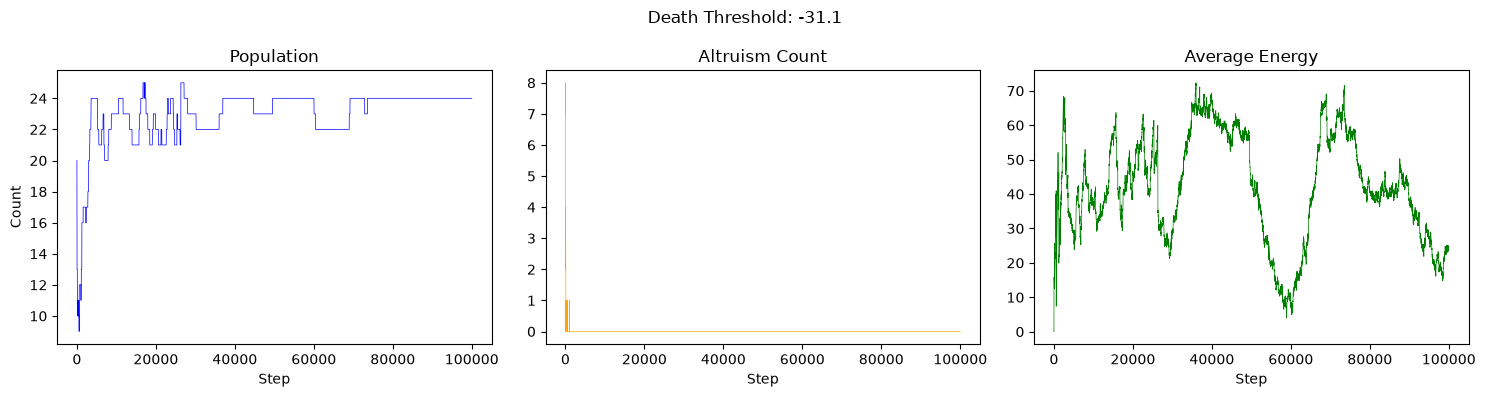

Plotting: death_threshold= -10.0


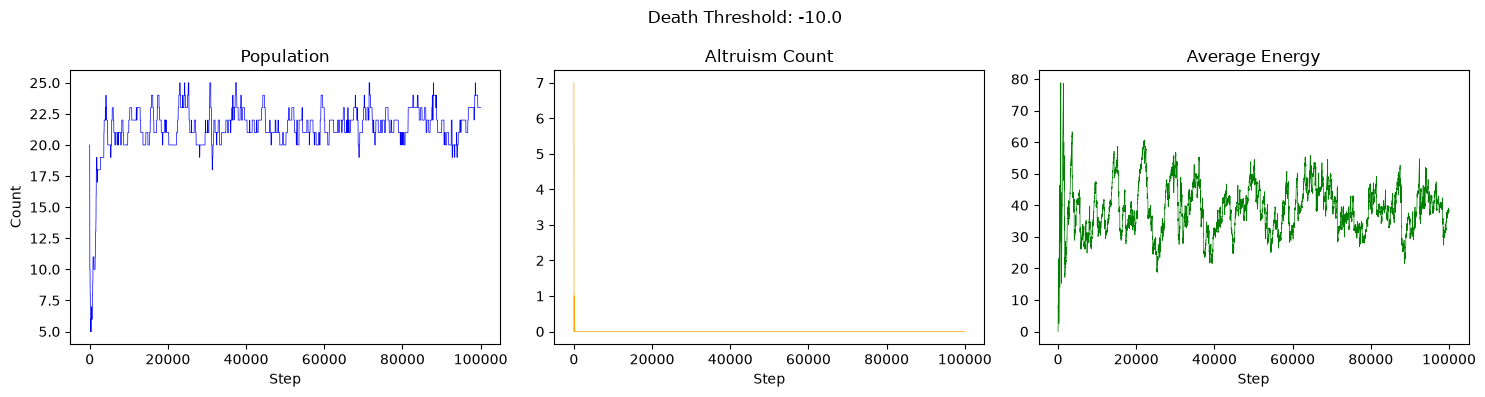

In [7]:
def main():
    csv_path = DATA_DIR / "simulation_history.csv"
        
    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)
    
    grouped = df.groupby('death_threshold')
    
    print("Generating plots...")
    for dt, subset in grouped:
        print(f"Plotting: death_threshold={dt:6.1f}")
        plot_and_save_history(dt, subset)

if __name__ == "__main__":
    main()

In [69]:
import seaborn as sns

In [70]:
df = pd.read_csv("../data/grid_search_results.csv")
df.head()

,death_threshold,transfer_amount,avg_majority_altruism_steps
0,-200.0,0.500,0.0
1,-200.0,1.625,0.0
2,-200.0,2.750,0.0
3,-200.0,3.875,0.0
4,-200.0,5.000,0.0


In [71]:
pivot_df = df.pivot(
        columns="transfer_amount", 
        index="death_threshold",
        values="avg_majority_altruism_steps"
    )

In [72]:
pivot_df = pivot_df.sort_index(ascending=False)

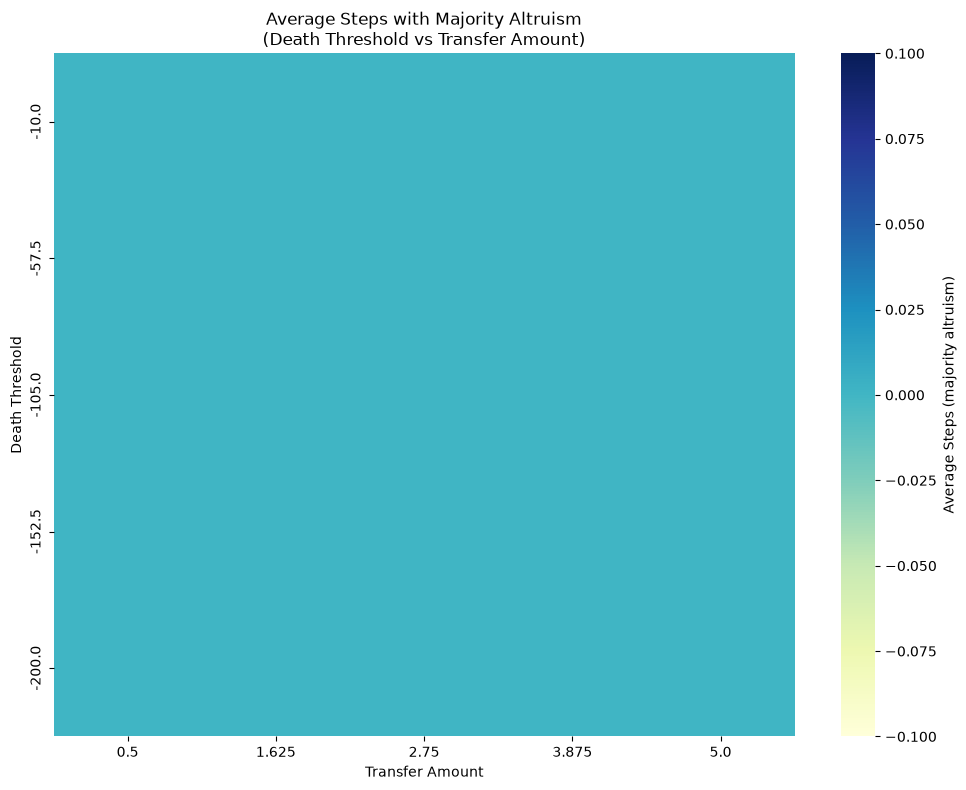

In [73]:
# draw heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_df, 
    annot=False,      
    fmt=".1f",       
    cmap="YlGnBu",   
    cbar_kws={'label': 'Average Steps (majority altruism)'}
)
plt.title(f"Average Steps with Majority Altruism\n(Death Threshold vs Transfer Amount)")
plt.xlabel("Transfer Amount")
plt.ylabel("Death Threshold")
plt.tight_layout()

plt.show()
